# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [15]:
# Load data dari file CSV
df = pd.read_csv("hasil_clustering_bank.csv")

# Tampilkan beberapa baris pertama untuk memastikan data terload dengan benar
df

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Cluster
0,14.09,Debit,San Diego,ATM,Lansia,Doctor,81,1,5112.21,2024-11-04 08:08:08,2
1,376.24,Debit,Houston,ATM,Lansia,Doctor,141,1,13758.91,2024-11-04 08:09:35,0
2,126.29,Debit,Mesa,Online,Dewasa Muda,Student,56,1,1122.35,2024-11-04 08:07:04,1
3,184.50,Debit,Raleigh,Online,Dewasa Muda,Student,25,1,8569.06,2024-11-04 08:09:06,2
4,13.45,Credit,Atlanta,Online,Dewasa Muda,Student,198,1,7429.40,2024-11-04 08:06:39,2
...,...,...,...,...,...,...,...,...,...,...,...
2507,856.21,Credit,Colorado Springs,Branch,Dewasa,Doctor,109,1,12690.79,2024-11-04 08:11:29,0
2508,251.54,Debit,Tucson,Branch,Dewasa,Doctor,177,1,254.75,2024-11-04 08:11:42,1
2509,28.63,Debit,San Diego,Branch,Lansia Muda,Retired,146,1,3382.91,2024-11-04 08:08:39,1
2510,185.97,Debit,Denver,Online,Dewasa Muda,Student,19,1,1776.91,2024-11-04 08:12:22,1


In [16]:
# Preprocessing
object_df = df.select_dtypes(include='object').columns.tolist()
numeric_df = df.select_dtypes(exclude='object').columns.tolist()[:-1]

In [17]:
# Melakukan label encoding pada kategori umur
label_encoder = LabelEncoder()
df["CustomerAge"] = label_encoder.fit_transform(df["CustomerAge"])

In [18]:
# Encode the categorical features
df_encoded = df.copy()
for col in object_df:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    
df_encoded.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Cluster
0,14.09,1,36,0,2,0,81,1,5112.21,105,2
1,376.24,1,15,0,2,0,141,1,13758.91,192,0
2,126.29,1,23,2,1,3,56,1,1122.35,41,1
3,184.50,1,33,2,1,3,25,1,8569.06,163,2
4,13.45,0,1,2,1,3,198,1,7429.40,16,2


# **3. Data Splitting**

Membagi data train (80%) dan data test (20%)

In [19]:
# Menentukan Fitur dan target
X = df_encoded.drop('Cluster', axis=1)
y = df_encoded['Cluster']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40, stratify=y)

In [20]:
# Simple check 
y_train.value_counts(), y_test.value_counts()

(Cluster
 1    920
 2    753
 0    336
 Name: count, dtype: int64,
 Cluster
 1    230
 2    189
 0     84
 Name: count, dtype: int64)

# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Algoritma yang dipilih adalah 
1. K-Nearest Neighbors (KNN)
2. Naive Bayes

#### Membangun model K-Nearest Neighbors (KNN)

In [21]:
# Inisialisasi model KNN dengan default parameter
knn = KNeighborsClassifier()

# Latih model
knn.fit(X_train, y_train)

# Prediksi
y_pred_knn = knn.predict(X_test)

Pada kode di atas, algoritma K-Nearest Neighbors (KNN) digunakan dengan parameter default, di mana nilai K = 5. KNN bekerja dengan mencari 5 tetangga terdekat berdasarkan jarak Euclidean dan menentukan kelas sampel baru berdasarkan mayoritas dari tetangga tersebut. Model ini dilatih menggunakan X_train dan y_train, kemudian digunakan untuk memprediksi X_test

#### Membangun model Naïve Baye

In [22]:
# Inisialisasi model
nb = GaussianNB()

# Latih model
nb.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_nb = nb.predict(X_test)

## **b. Evaluasi Model Klasifikasi**

Evaluasi model dilakukan dengan:
1. Prediksi data uji
2. Metrik Evaluasi Accuracy Precision, Recall dan F1-Score
3. Confusion Matrix

Akurasi KNN: 0.9940357852882704
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        84
           1       1.00      1.00      1.00       230
           2       0.98      1.00      0.99       189

    accuracy                           0.99       503
   macro avg       0.99      0.99      0.99       503
weighted avg       0.99      0.99      0.99       503



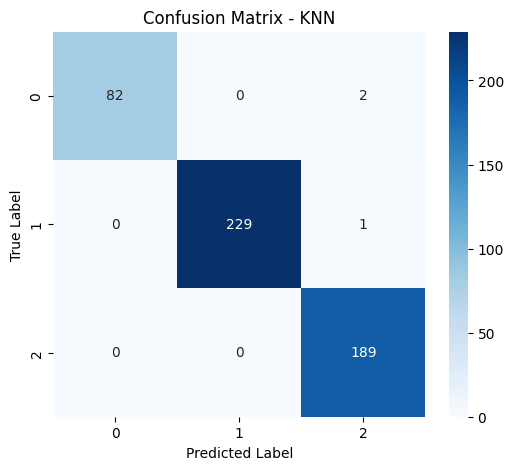

In [23]:
# Evaluasi model KNN
print("Akurasi KNN:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test), yticklabels=set(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - KNN")
plt.show()

Model K-Nearest Neighbors (KNN) mencapai akurasi 99,4%, yang menunjukkan bahwa model ini mampu mengklasifikasikan data dengan sangat baik. Dari confusion matrix, terlihat bahwa hampir semua prediksi benar dengan hanya sedikit kesalahan, yaitu 2 sampel kelas 0 diklasifikasikan sebagai kelas 2 dan 1 sampel kelas 1 diklasifikasikan sebagai kelas 2. Model ini memiliki precision, recall, dan F1-score yang sangat tinggi untuk semua kelas, menunjukkan bahwa KNN mampu menangkap pola dalam data dengan baik.

Akurasi Naïve Bayes: 0.9403578528827038
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        84
           1       0.99      0.96      0.97       230
           2       0.91      0.94      0.92       189

    accuracy                           0.94       503
   macro avg       0.93      0.93      0.93       503
weighted avg       0.94      0.94      0.94       503



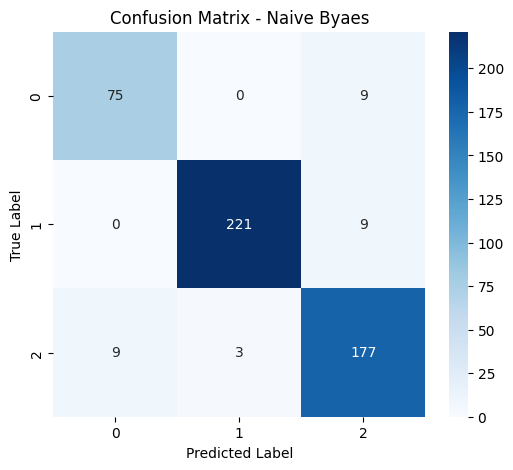

In [24]:
# Evaluasi model Naive Bayes
print("Akurasi Naïve Bayes:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test), yticklabels=set(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Naive Byaes")
plt.show()

Model Naïve Bayes memiliki akurasi 94,0%, yang lebih rendah dibandingkan KNN. Dari confusion matrix, terlihat bahwa kelas 0 dan kelas 2 mengalami lebih banyak kesalahan klasifikasi dibandingkan dengan KNN, terutama di mana 9 sampel kelas 0 diklasifikasikan sebagai kelas 2, dan 9 sampel kelas 2 diklasifikasikan sebagai kelas 0. Hal ini menunjukkan bahwa Naïve Bayes kurang efektif dalam menangani distribusi data tertentu dibandingkan KNN, terutama jika asumsi independensi fitur tidak sepenuhnya terpenuhi.

**Perbandingan KNN vs Naive Bayes:**

Secara keseluruhan, KNN lebih unggul dibandingkan Naïve Bayes, dengan akurasi yang lebih tinggi dan jumlah kesalahan klasifikasi yang lebih sedikit. KNN lebih cocok digunakan ketika jumlah data yang tersedia cukup besar dan pola antar fitur memiliki keterkaitan yang kuat. Sementara itu, Naïve Bayes lebih cepat dalam prediksi dan dapat bekerja lebih baik jika fitur memiliki distribusi yang mendukung asumsi independensi. Namun, dalam kasus ini, KNN memberikan hasil yang lebih akurat dan presisi dibandingkan Naïve Bayes.

## **c. Tuning Model Klasifikasi**

Disini saya akan mencoba hyperparameter Tuning pada Naive Bayes dengan GridSearchCV

In [27]:
# Definisikan model
nb = GaussianNB()

# Definisikan parameter yang ingin dituning
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
}

# Lakukan GridSearchCV
grid_search = GridSearchCV(nb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Model dengan parameter terbaik
best_nb = grid_search.best_estimator_
y_pred_best_nb = best_nb.predict(X_test)

## **d. Evaluasi Model Klasifikasi setelah Tuning**

Menggunakan model dari hyperparameter terbaik dan mengevaluasinya

Akurasi Naïve Bayes dengan Hyperparameter Tuning: 0.9662027833001988
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        84
           1       1.00      0.97      0.98       230
           2       0.93      0.98      0.96       189

    accuracy                           0.97       503
   macro avg       0.97      0.96      0.96       503
weighted avg       0.97      0.97      0.97       503



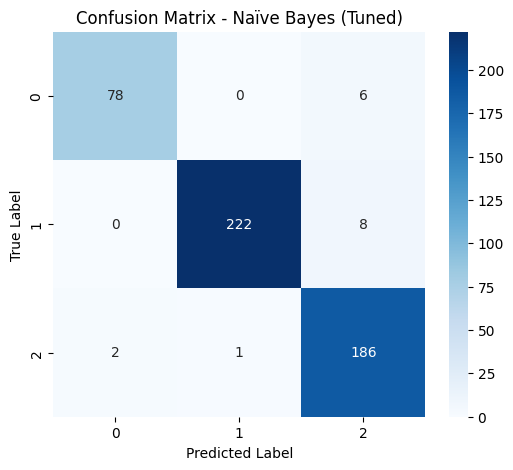

In [26]:
# Evaluasi model dengan parameter terbaik
print("Akurasi Naïve Bayes dengan Hyperparameter Tuning:", accuracy_score(y_test, y_pred_best_nb))
print(classification_report(y_test, y_pred_best_nb))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best_nb)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test), yticklabels=set(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Naïve Bayes (Tuned)")
plt.show()

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

#### Perbandingan Evaluasi Naïve Bayes Sebelum & Setelah Hyperparameter Tuning

##### 1. Perbandingan Akurasi
- **Sebelum Tuning:** 94.04%  
- **Setelah Tuning:** 96.62% (+2.58%)  
- Peningkatan akurasi menunjukkan tuning berhasil meningkatkan performa.

##### 2. Perbandingan Precision, Recall, dan F1-Score
- **Kelas 2:** Precision naik dari 91% menjadi 93%, Recall dari 94% menjadi 98%.  
- Kinerja model lebih stabil dengan kesalahan klasifikasi yang lebih sedikit.

##### 3. Perbandingan Confusion Matrix
- **Sebelum Tuning:** Lebih banyak kesalahan prediksi pada kelas 2.  
- **Setelah Tuning:** Kesalahan klasifikasi berkurang, terutama untuk kelas 2.

##### 4. Identifikasi Kelemahan Model
- **Sebelum Tuning:** Kurang akurat dalam memprediksi kelas 2.  
- **Setelah Tuning:** Performa meningkat, tetapi masih ada sedikit kesalahan prediksi.

##### 5. Overfitting atau Underfitting?
- Model tetap generalisasi dengan baik dan tidak mengalami overfitting.

##### 6. Rekomendasi Tindakan Lanjutan
- Coba model lain seperti **Random Forest atau SVM**.  
- Lakukan **Feature Engineering** untuk meningkatkan performa.  
- Tambah data agar model lebih robust.

**Kesimpulan:** Hyperparameter tuning berhasil meningkatkan akurasi dan mengurangi kesalahan klasifikasi.
